In [2]:
from keras.utils import image_dataset_from_directory
from keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D, Conv2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import pickle
import cv2
import os
import shutil
from PIL import Image

In [130]:
train_ds=image_dataset_from_directory('../train_test_val_data/train_oversampling',seed=42,batch_size=16,image_size=(363,360),shuffle= False)
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('../train_test_val_data/val',seed=42,batch_size=16,image_size=(363,360),label_mode='int', shuffle= False)
test_ds=image_dataset_from_directory('../train_test_val_data/test',seed=42,batch_size=16,image_size=(363,360),label_mode='int', shuffle= False)

Found 18640 files belonging to 8 classes.
Found 2564 files belonging to 8 classes.
Found 2569 files belonging to 8 classes.


The shape of the original image is: (363, 360, 3) 

The range of the original image is from 0.0 to  255.0


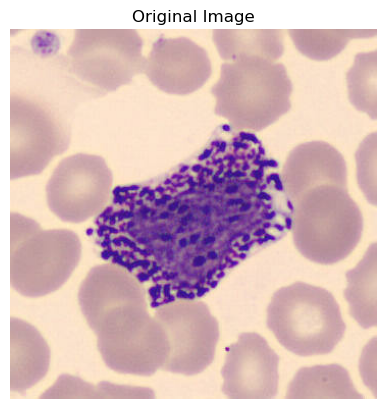

In [132]:
original_image = next(iter(train_ds))[0]
print('The shape of the original image is:', original_image[15].shape,"\n")
plt.imshow(original_image[15].numpy().astype('uint8'))
plt.axis('off')
plt.title("Original Image");

print("The range of the original image is from",np.min(original_image), "to ", np.max(original_image))

In [133]:
train_ds=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds=test_ds.map(lambda x,y:(preprocess_input(x),y))

The shape of the preprocessed image is: (363, 360, 3) 

The range of the preprocessed image is from  -116.779 to  138.22101


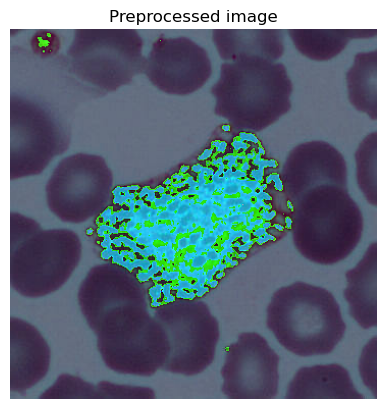

In [135]:
preprocessed_image = next(iter(train_ds))[0]
print('The shape of the preprocessed image is:', preprocessed_image[15].shape,"\n")
plt.imshow(preprocessed_image[15].numpy().astype('uint8'))
plt.axis('off')
plt.title("Preprocessed image");

print("The range of the preprocessed image is from ",np.min(preprocessed_image),"to ", np.max(preprocessed_image))


The range of the values in the image are from -111.51097106933594 to 131.32000732421875


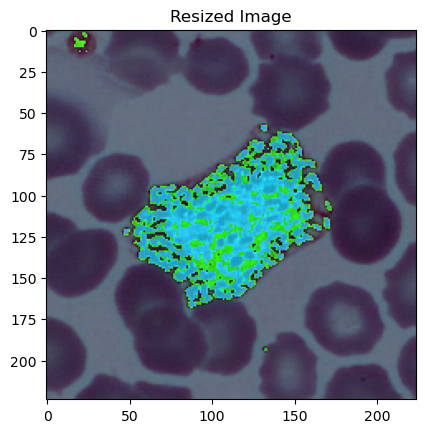

In [136]:
y = Resizing(224,224)(preprocessed_image[15])
print(f"The range of the values in the image are from {np.min(y.numpy())} to {np.max(y.numpy())}")
plt.imshow(y.numpy().astype('uint8'))
plt.title("Resized Image");

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43729794..0.51498044].



The range of the values in the image are from -0.4372979402542114 to 0.5149804353713989


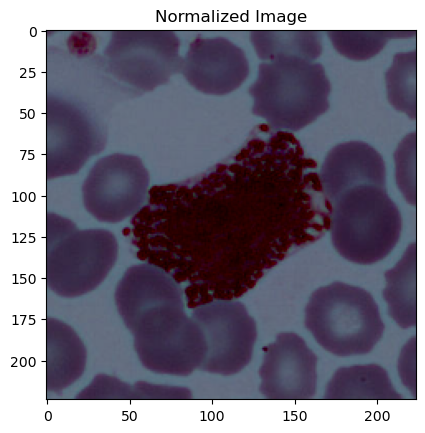

In [139]:
z = Rescaling(1./255)(y)
print(f"\nThe range of the values in the image are from {np.min(z.numpy())} to {np.max(z.numpy())}")
plt.imshow(z.numpy().astype('float32'));
plt.title("Normalized Image");


In [ ]:
base_model=VGG16(weights='imagenet',include_top=False)
for layer in base_model.layers[-4:]:
    layer.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False
inputs=Input(shape=(363,360,3))
x=Resizing(224,224)(inputs)
x=Rescaling(1./255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

In [ ]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

In [7]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 363, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,768,904 (60.15 MB)

 Trainable params: 8,133,640 (31.03 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=5,             # wait 5 epochs before stopping
    mode='min',min_delta=0.001,
    restore_best_weights=True  # keep the best weights
)
reduceLR=ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=3,
                           min_delta=0.001,cooldown=4)

In [17]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs = 5,callbacks=[early_stopping,reduceLR])

Epoch 1/5
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 2043s 2s/step - accuracy: 0.3108 - loss: 1.6970 - val_accuracy: 0.7379 - val_loss: 0.7350 - learning_rate: 0.0010
Epoch 2/5
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 2436s 2s/step - accuracy: 0.8666 - loss: 0.3954 - val_accuracy: 0.9353 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 3/5
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 2107s 2s/step - accuracy: 0.9496 - loss: 0.1617 - val_accuracy: 0.9610 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 4/5
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 3123s 3s/step - accuracy: 0.9644 - loss: 0.1179 - val_accuracy: 0.9618 - val_loss: 0.1242 - learning_rate: 0.0010
Epoch 5/5
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 2822s 2s/step - accuracy: 0.9705 - loss: 0.0929 - val_accuracy: 0.9618 - val_loss: 0.1401 - learning_rate: 0.0010


In [18]:
model.save("vgg16_5epochs.keras")

In [10]:
model = load_model("vgg16_5epochs.keras")

In [11]:
X = np.array([img.numpy() for img, _ in val_ds.take(2)][0]).astype(np.uint8)
y = np.array([label.numpy() for _, label in val_ds.take(2)][0])

# Select specific images
images = X[:4]
labels = y[:4]



In [ ]:
target_layer = model.get_layer('vgg16').get_layer('block5_conv3')
grad_model = Model(inputs = base_model.input, outputs = [target_layer.output, model.output])
img = tf.expand_dims(images[0], axis=0)


with tf.GradientTape() as tape:
    conv_outs, preds = grad_model(img)

In [97]:
def grad_cam(img, trained_model, conv_name):
    vgg16 = trained_model.get_layer("vgg16")
    layer = vgg16.get_layer(conv_name)
    
    # model that outputs the activations of conv layer and predictions of model
    grad_model = Model(inputs = trained_model.input, outputs = [layer.output, trained_model.output])
    
    img = tf.expand_dims(img, axis=0)
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        predicted_class = tf.argmax(predictions[0]) 
        loss = tf.gather(predictions[0], predicted_class)
     
    # Gradients of the score with respect to the outputs of the convolutional layer
    grads = tape.gradient(loss, conv_outputs)
    
    # Weighted average of the gradients for each channel
    pooled_grads = tf.reduce_mean(grads, axis = (0,1,2))
    
    # Weight the activations by the calculated gradients
    conv_outputs = conv_outputs[0] # remove the batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    
    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) # Take only the positive values
    heatmap /= tf.math.reduce_max(heatmap)  # Normalize between 0 and 1
    heatmap = heatmap.numpy() #Convert to numpy for visualization pursposes
    
    # Resize the heatmap to match the original image size
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[1], img.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)  # Remove the singleton dimension at the end of the heatmap_resized 
    
    # Color the heatmap with a palette (e.g., "jet")
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]  # Get the R, G, B channels 

    superimposed_image = heatmap_colored * 0.7 + img[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class

In [57]:
model.layers

[<InputLayer name=input_layer_5, built=True>,
 <Resizing name=resizing_1, built=True>,
 <Rescaling name=rescaling_1, built=True>,
 <Functional name=vgg16, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_4, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_5, built=True>]

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m2530293367728\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 363, 360, 3), dtype=uint8)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

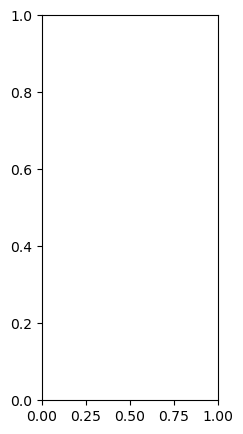

In [37]:


for i in range(len(images)):
    fig = plt.figure(figsize=(5,5))
    fig.add_subplot(1,2,1)
    overlaid_img, predicted_class = grad_cam(images[i], model, 'block5_conv3')
    plt.imshow(overlaid_img)
    plt.axis("off")
    plt.title("Grad-Cam overlaid")
    fig.add_subplot(1,2,2)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("original")
    

In [ ]:
model=load_model('vgg16_model_fine_tuning_firstLayers.h5')
with open('training_history_vgg_fine_tuning_firstLayers.pkl', 'rb') as f:
    data=pickle.load(f)

In [ ]:
print(data.keys())

In [ ]:
# loss=history_model.history['loss']
# val_loss=history_model.history['val_loss']
# accuracy=history_model.history['accuracy']
# val_accuracy=history_model.history['val_accuracy']
pplt.use_style()
loss=data['loss']
val_loss=data['val_loss']
accuracy=data['accuracy']
val_accuracy=data['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc_vgg16.pdf');

In [ ]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm_vgg16.pdf')
plt.show()

In [ ]:
import pickle

with open('training_history_vgg_fine_tuning_firstLayers.pkl', 'wb') as f:
    pickle.dump(history_model.history, f)

In [ ]:
model.save('vgg16_model_fine_tuning_firstLayers.h5')

In [ ]:
img_path='../test/basophil/BA_580.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

In [ ]:
# Target last conv layer (you can change this depending on your model)
last_conv_layer_name = 'block5_conv3'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [base_model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of the predicted class with respect to output of conv layer
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))  # [channels]

    conv_outputs = conv_outputs[0]  # [height, width, channels]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')

# Display it over original image
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))  # model resizes to 224x224
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    # Show
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()

display_gradcam(img_path, heatmap)